# Bibliotekos

In [270]:
import pandas as pd
import numpy as np
import torch
torch.cuda.is_available()
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import spearmanr
from skorch import NeuralNetRegressor
from skorch.callbacks import Checkpoint, EarlyStopping
from skorch.dataset import ValidSplit

from pyts.decomposition import SingularSpectrumAnalysis

from Lasso import select_features_lasso

from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import GridSearchCV

from sklearn.base import BaseEstimator, RegressorMixin
from skorch import NeuralNetRegressor

from sklearn.metrics import make_scorer, root_mean_squared_error

# Duomenų paruošimas

In [271]:
data = pd.read_csv("../datasets_prep/dm_project_dataset.csv")

data['observationTime'] = pd.to_datetime(data['observationTime'])
data['month'] = data['observationTime'].dt.month
data['day_of_year'] = data['observationTime'].dt.dayofyear
data['day_of_week'] = data['observationTime'].dt.dayofweek

data['month_sin'] = np.sin(2 * np.pi * data['month'] / 12)
data['month_cos'] = np.cos(2 * np.pi * data['month'] / 12)

lag_config = {
    'H2O_column_number_density': [1],
    'NO2_column_number_density': [1, 2, 3],
    'nmvoc': [1],
    'nh3': [1, 2, 11],
    'pm10': [1],
    'pans': [10],
    'dust': [1],
    'NO2': np.arange(1, 10, 1)
}

for feature, lags in lag_config.items():
    for lag in lags:
        data[f'{feature}_lag{lag}'] = data[feature].shift(lag)

# data['target'] = data['missforest_precipitation'].shift(-1)
data = data.dropna()

drop_names = [
    'observationTime',
    # 'absorbing_aerosol_index',
    # 'NO2_column_number_density',
    # 'stratospheric_NO2_column_number_density',
    # 'NO2_slant_column_number_density',
    # 'tropopause_pressure',
    # 'H2O_column_number_density',
    # 'BrO',
    # 'BrO_Error',
    # 'NO2',
    # 'NO2_Error',
    # 'O3',
    # 'O3_Error',
    # 'pm10',
    # 'pm2p5',
    # 'sia',
    # 'nmvoc',
    # 'dust',
    # 'nh3',
    # 'pans',
    # 'tp',
    # 't2m',
    # 'airTemperature',
    # 'seaLevelPressure',
    # 'relativeHumidity',
    # 'missforest_precipitation',
    # 'xgb_cloudCover',
    # 'feelsLikeTemperature_fixed',
    # 'windSpeed_fixed',
    # 'windGust_fixed',
    # 'windDirection_fixed',
    # 'month_cos',
    # 'month_sin',
    # 'month',
    # 'day_of_year'
]

# X = data.drop(columns=drop_names)
X = data
# y = data['target']

In [272]:
X.head()

,observationTime,absorbing_aerosol_index,NO2_column_number_density,stratospheric_NO2_column_number_density,NO2_slant_column_number_density,tropopause_pressure,H2O_column_number_density,BrO,BrO_Error,NO2,...,dust_lag1,NO2_lag1,NO2_lag2,NO2_lag3,NO2_lag4,NO2_lag5,NO2_lag6,NO2_lag7,NO2_lag8,NO2_lag9
11,2018-07-12,-1.259574,0.000091,0.000061,0.000205,19223.746,2092.265400,1.413290e+13,1.937367e+13,3.779792e+15,...,0.042530,3.785389e+15,3.663516e+15,3.898540e+15,4.667088e+15,4.203628e+15,3.959520e+15,3.959891e+15,4.149200e+15,4.526218e+15
12,2018-07-13,-1.214123,0.000084,0.000065,0.000208,19219.334,2178.943600,3.610126e+13,1.652258e+13,3.688520e+15,...,0.006774,3.779792e+15,3.785389e+15,3.663516e+15,3.898540e+15,4.667088e+15,4.203628e+15,3.959520e+15,3.959891e+15,4.149200e+15
13,2018-07-14,-0.762476,0.000079,0.000063,0.000203,19222.883,2346.339133,3.659979e+13,1.520030e+13,4.186392e+15,...,0.011105,3.688520e+15,3.779792e+15,3.785389e+15,3.663516e+15,3.898540e+15,4.667088e+15,4.203628e+15,3.959520e+15,3.959891e+15
14,2018-07-15,-1.098520,0.000090,0.000057,0.000149,16677.404,2322.217746,3.449885e+13,1.453966e+13,3.940498e+15,...,0.017107,4.186392e+15,3.688520e+15,3.779792e+15,3.785389e+15,3.663516e+15,3.898540e+15,4.667088e+15,4.203628e+15,3.959520e+15
15,2018-07-16,-0.770874,0.000077,0.000062,0.000183,16673.053,2747.987500,3.512158e+13,1.647380e+13,3.581072e+15,...,0.037638,3.940498e+15,4.186392e+15,3.688520e+15,3.779792e+15,3.785389e+15,3.663516e+15,3.898540e+15,4.667088e+15,4.203628e+15


# SSA

In [273]:
# series = data['missforest_precipitation'].apply(lambda x: math.log(x+1)).values
series = np.log1p(data['missforest_precipitation'].values)

L = 90
n_comp = 90

ssa = SingularSpectrumAnalysis(window_size=L, lower_frequency_bound=0.1)

X_ssa = series.reshape(1, -1)
series_reshaped = series.reshape(1, -1)
all_components = ssa.fit_transform(series_reshaped)

# all_components forma po fit_transform yra (1, L, len(series))
# Ištraukiame tik komponentes:
components = all_components[0]

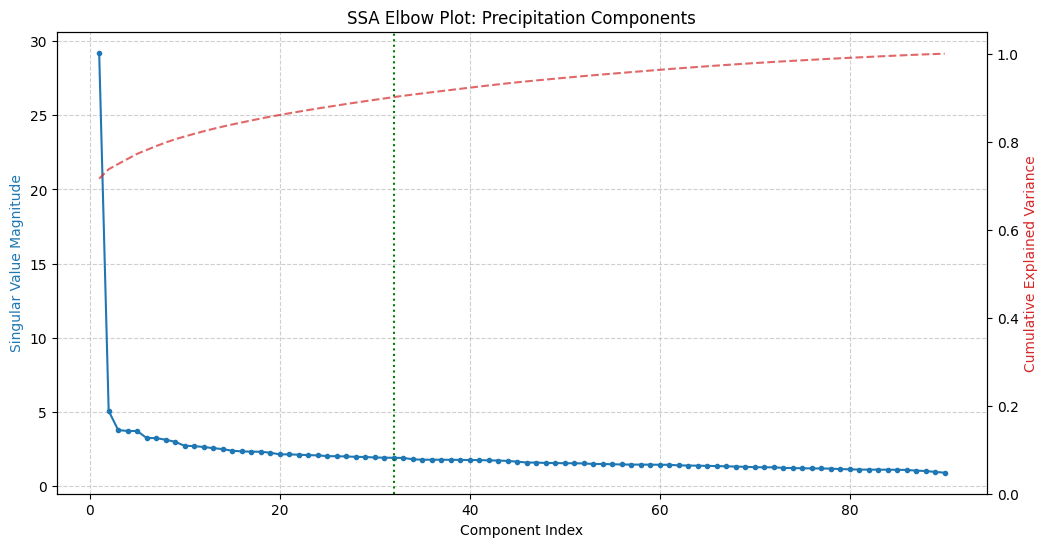

In [274]:
component_energies = np.array([np.sum(c**2) for c in components])
singular_values = np.sqrt(component_energies)

# 2. Sort them (SSA components are usually already sorted)
idx = np.argsort(singular_values)[::-1]
singular_values = singular_values[idx]

# 3. Calculate Variance Explained
total_var = np.sum(singular_values**2)
explained_variance = (singular_values**2) / total_var
cumulative_variance = np.cumsum(explained_variance)

# --- PLOTTING ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Singular Values (The Elbow)
ax1.plot(range(1, L + 1), singular_values, marker='o', markersize=3, color='tab:blue', label='Singular Values')
ax1.set_xlabel('Component Index')
ax1.set_ylabel('Singular Value Magnitude', color='tab:blue')
ax1.set_title('SSA Elbow Plot: Precipitation Components')
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot Cumulative Variance (To see how much info you keep)
ax2 = ax1.twinx()
ax2.plot(range(1, L + 1), cumulative_variance, color='tab:red', linestyle='--', alpha=0.7, label='Cumulative Variance')
ax2.set_ylabel('Cumulative Explained Variance', color='tab:red')
ax2.set_ylim(0, 1.05)

# Add a vertical line at a suggested cutoff (e.g., where 90% variance is reached)
cutoff_90 = np.where(cumulative_variance >= 0.90)[0][0] + 1
ax1.axvline(x=cutoff_90, color='green', linestyle=':', label=f'90% Var ({cutoff_90} comps)')

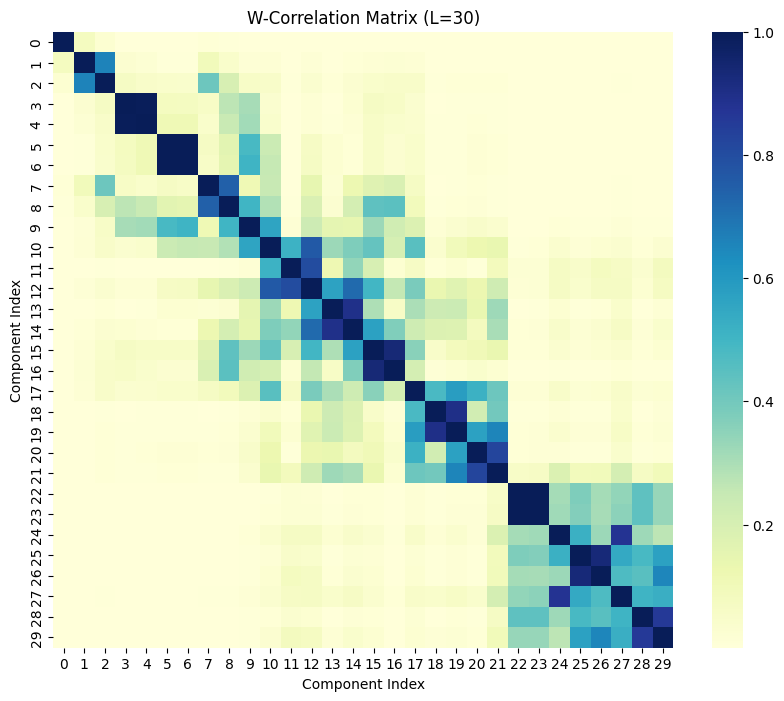

In [275]:
def plot_w_correlation(components):
    L, N = components.shape
    # Define the weights (w_i)
    # This reflects how many times each observation was used in the trajectory matrix
    K = N - L + 1
    w = np.array([min(i + 1, L, N - i) for i in range(N)])
    
    w_corr = np.zeros((L, L))
    
    # Calculate weighted norms once for efficiency
    weighted_norms = [np.sqrt(np.sum(w * (c**2))) for c in components]
    
    for i in range(L):
        for j in range(i, L):
            numerator = np.sum(w * components[i] * components[j])
            denominator = weighted_norms[i] * weighted_norms[j]
            val = abs(numerator / denominator)
            w_corr[i, j] = val
            w_corr[j, i] = val # Matrix is symmetric
            
    # Plotting
    plt.figure(figsize=(10, 8))
    sns.heatmap(w_corr, cmap='YlGnBu', annot=False)
    plt.title(f'W-Correlation Matrix (L={L})')
    plt.xlabel('Component Index')
    plt.ylabel('Component Index')
    plt.show()
    
    return w_corr

# Use it on your first 20-30 components (plotting 365 is too dense to read)
w_matrix = plot_w_correlation(components[:30])

C:\Users\crist\AppData\Local\Temp\ipykernel_21496\1079277040.py:37: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


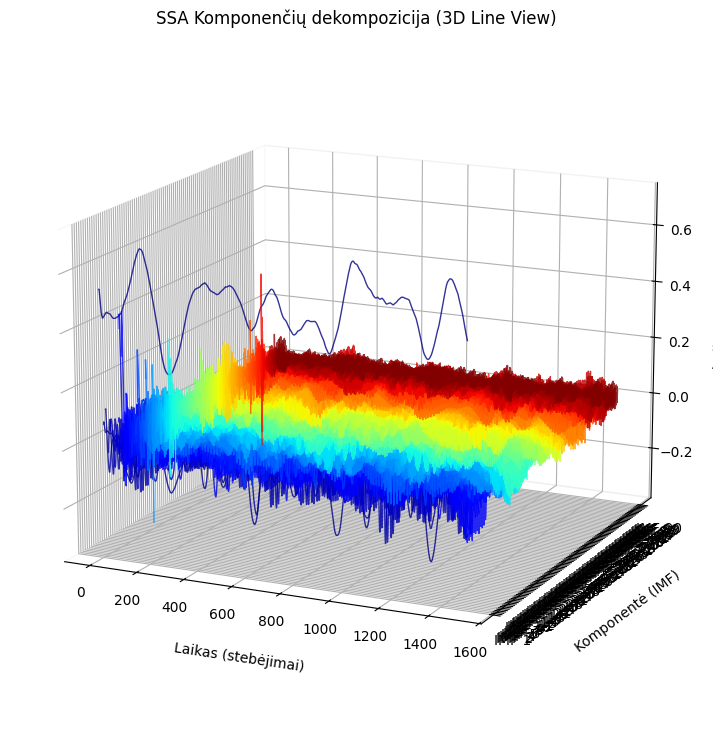

In [276]:
fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection='3d')
# Nustatome segmentą vizualizacijai (pvz., pirmos 1500 valandų)
n_points = min(1500, len(series))
x = np.arange(n_points)
zs = np.arange(n_comp)

# Spalvų paletė
colors = plt.cm.jet(np.linspace(0, 1, n_comp))

for i in range(n_comp):
    y = components[i][:n_points]
    # Kiekvieną komponentę nubraižome kaip liniją tam tikrame gylio (z) lygmenyje
    # Naudojame plot() funkciją, kur y ašis (gylis) yra konstanta 'i'
    ax.plot(x, [i] * n_points, y, color=colors[i], linewidth=1, alpha=0.8)

# 3. Estetika ir kampas (kad būtų kaip image_4a4242.jpg)
ax.set_xlabel('Laikas (stebėjimai)', labelpad=15)
ax.set_ylabel('Komponentė (IMF)', labelpad=15)
ax.set_zlabel('Krituliai (mm)', labelpad=10)

# Kameros nustatymai: 
# elev (aukštis virš horizonto) - mažesnis skaičius žiūri labiau iš priekio
# azim (pasukimas aplink Z ašį) - nustatykite pagal tai, kiek "šono" norite matyti
ax.view_init(elev=15, azim=-65) 

# Nuimame pilką foną, kad būtų švariau (panašiai kaip pavyzdyje)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

# Nustatome y ašies žymas (komponenčių numerius)
ax.set_yticks(zs)
ax.set_yticklabels([f'IMF {i+1}' for i in zs])

plt.title("SSA Komponenčių dekompozicija (3D Line View)")
plt.tight_layout()
plt.show()

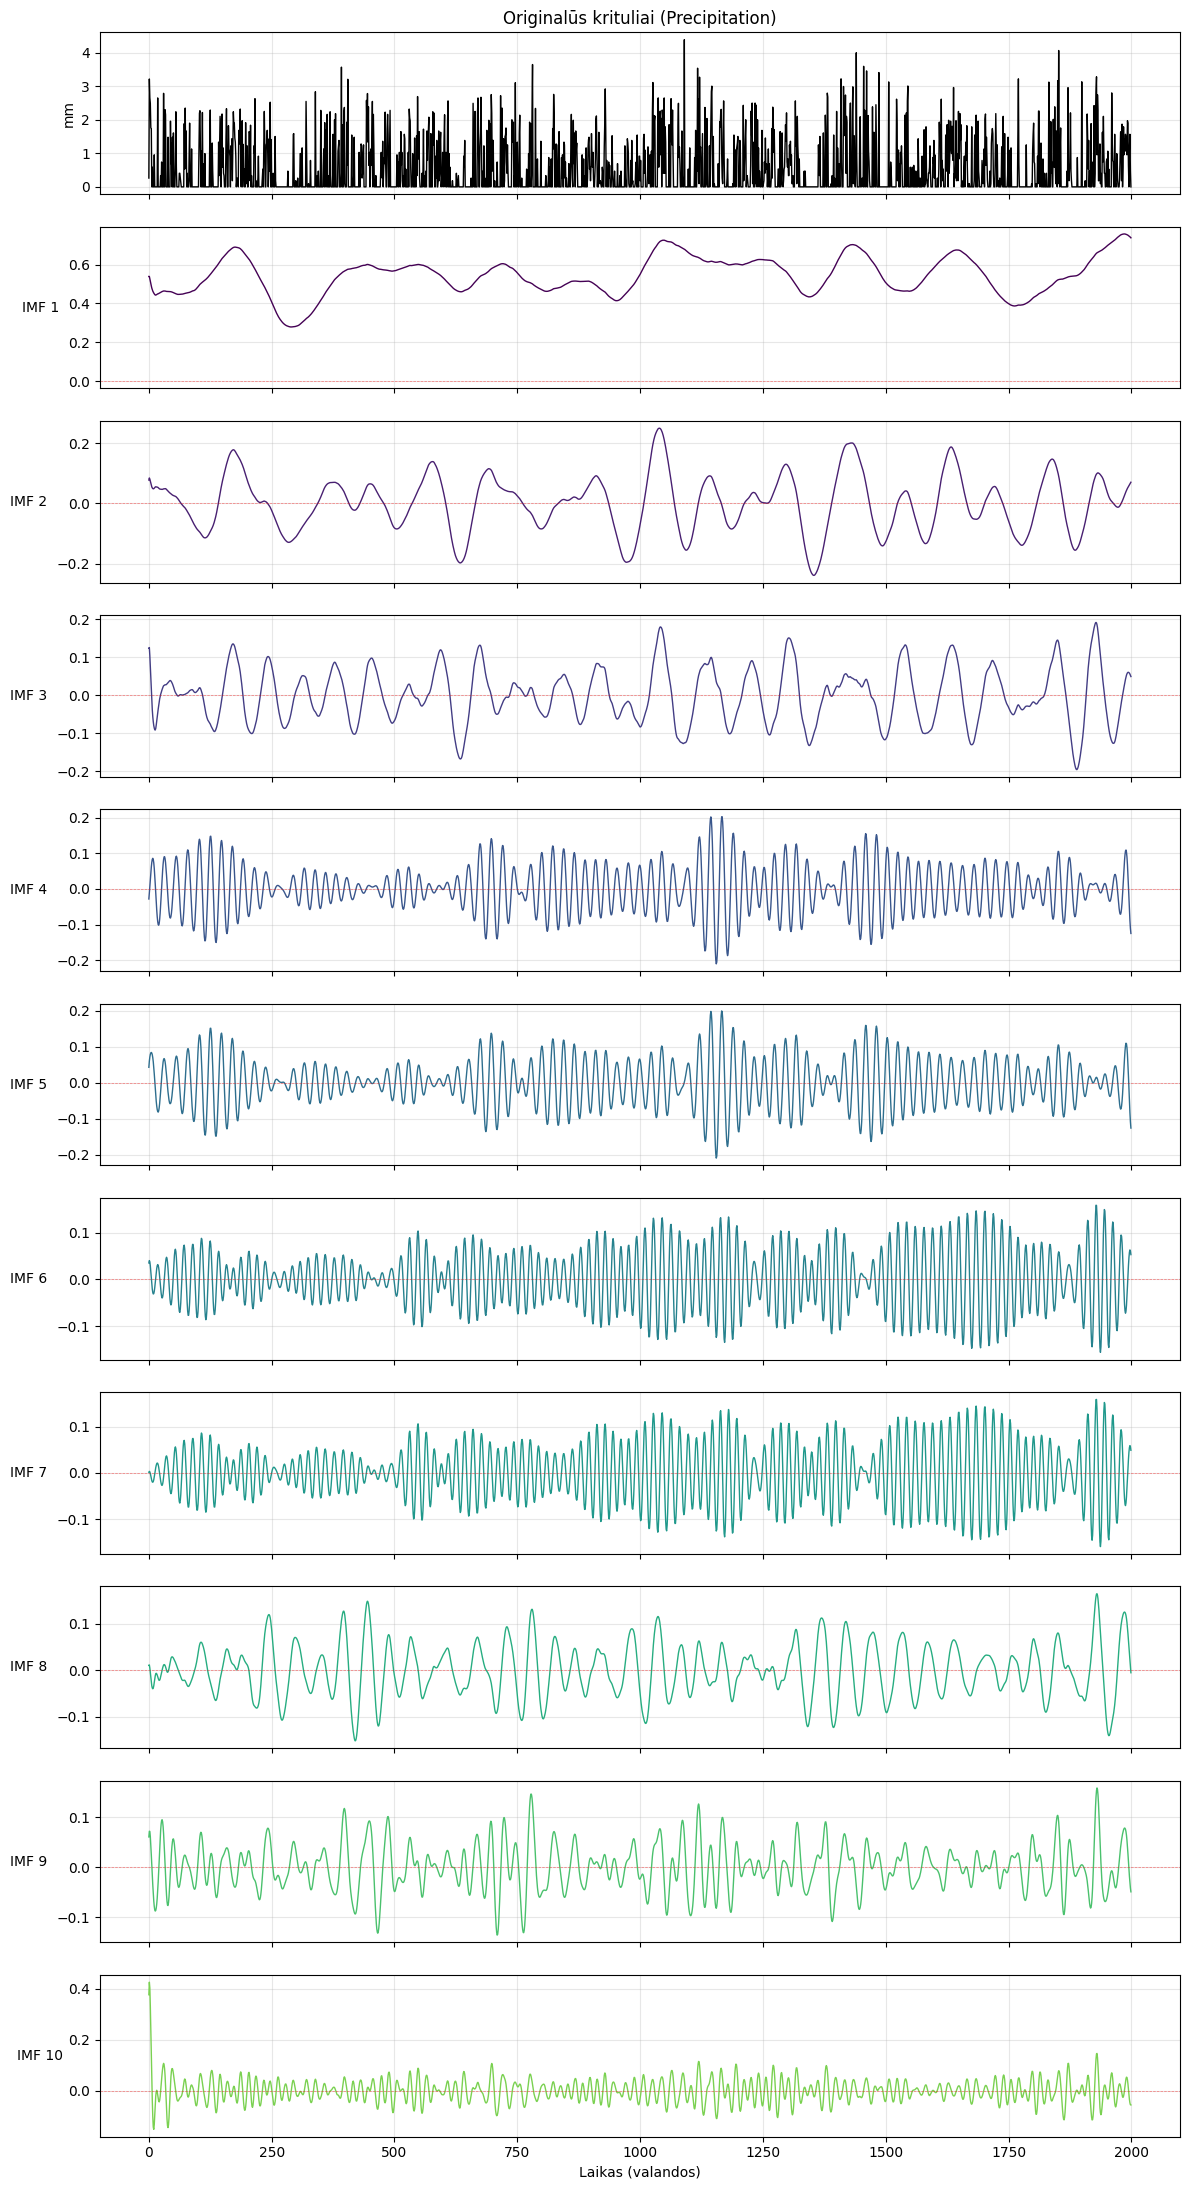

In [277]:
N = 10

fig, axes = plt.subplots(N + 1, 1, figsize=(12, 2 * (N + 1)), sharex=True)

# Nustatome segmentą vizualizacijai (pvz., pirmos 2000 valandų)
n_points = min(2000, len(series))
time_axis = np.arange(n_points)

# Viršutinis grafikas - Originalūs duomenys
axes[0].plot(time_axis, series[:n_points], color='black', linewidth=1)
axes[0].set_title('Originalūs krituliai (Precipitation)', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylabel('mm')

# Komponenčių grafikai
colors = plt.cm.viridis(np.linspace(0, 0.8, N))

for i in range(N):
    ax = axes[i + 1]
    ax.plot(time_axis, components[i][:n_points], color=colors[i], linewidth=1)
    ax.set_ylabel(f'IMF {i+1}', rotation=0, labelpad=20, verticalalignment='center')
    ax.grid(True, alpha=0.3)
    
    # Pridedame nulio liniją geresniam matomumui
    ax.axhline(0, color='red', linestyle='--', linewidth=0.5, alpha=0.5)

# Ašies nustatymai
axes[-1].set_xlabel('Laikas (valandos)')

# Sutvarkome tarpus, kad grafikai nesuliptų
plt.tight_layout()
plt.subplots_adjust(hspace=0.2) # Galite pareguliuoti tarpus tarp grafikų

plt.show()

In [278]:
how_group = {
    '1': [0],
    '2': [1, 2],
    '3': [3, 4, 5, 6],
    '4': np.arange(7, 90)
}

grouped = []
for key in how_group:
    new_comp = np.zeros_like(components[0])
    for idx in how_group[key]:
        new_comp += components[idx]
    grouped.append(new_comp)

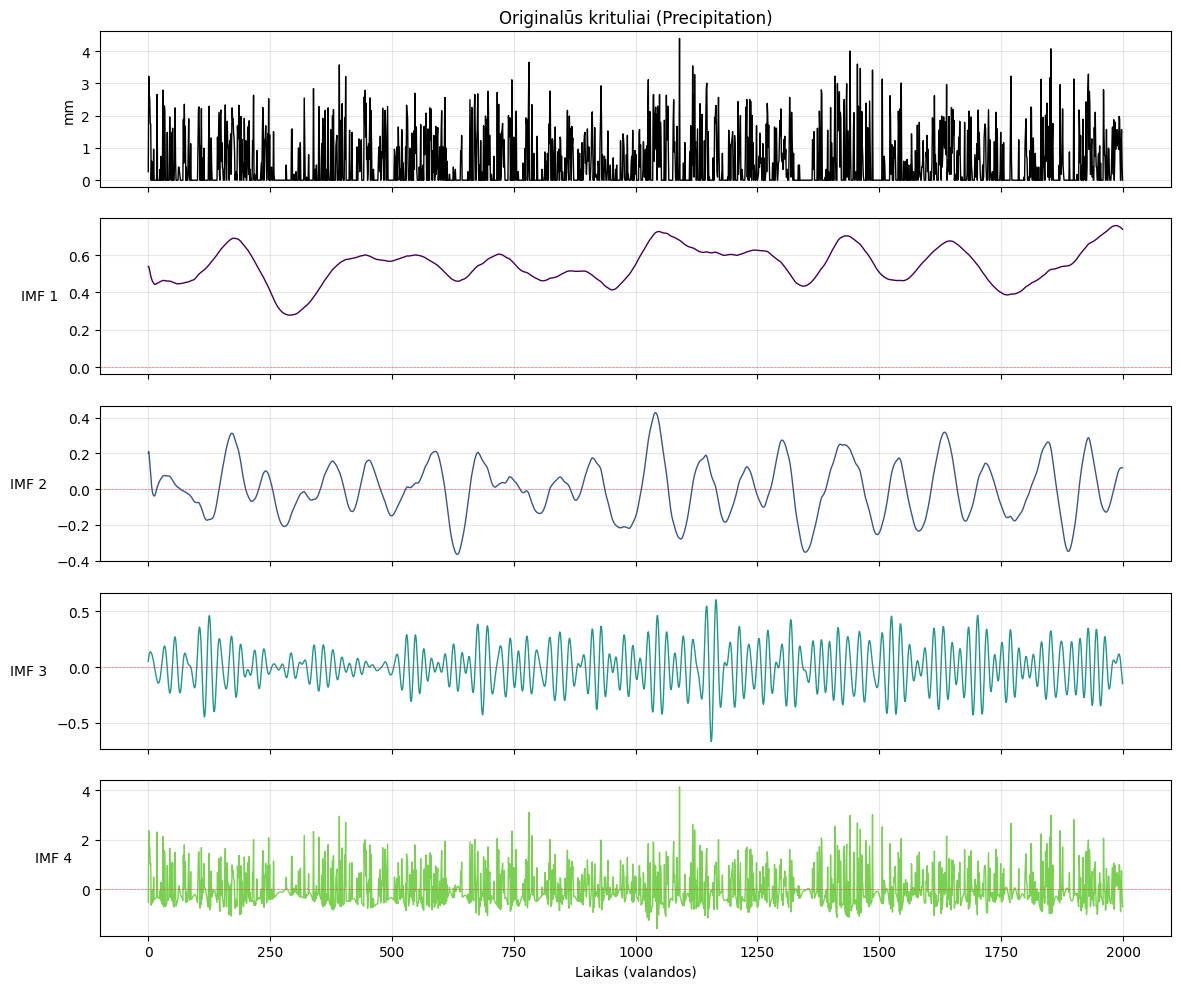

In [279]:
N = 4

fig, axes = plt.subplots(N + 1, 1, figsize=(12, 2 * (N + 1)), sharex=True)

# Nustatome segmentą vizualizacijai (pvz., pirmos 2000 valandų)
n_points = min(2000, len(series))
time_axis = np.arange(n_points)

# Viršutinis grafikas - Originalūs duomenys
axes[0].plot(time_axis, series[:n_points], color='black', linewidth=1)
axes[0].set_title('Originalūs krituliai (Precipitation)', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylabel('mm')

# Komponenčių grafikai
colors = plt.cm.viridis(np.linspace(0, 0.8, N))

for i in range(N):
    ax = axes[i + 1]
    ax.plot(time_axis, grouped[i][:n_points], color=colors[i], linewidth=1)
    ax.set_ylabel(f'IMF {i+1}', rotation=0, labelpad=20, verticalalignment='center')
    ax.grid(True, alpha=0.3)
    
    # Pridedame nulio liniją geresniam matomumui
    ax.axhline(0, color='red', linestyle='--', linewidth=0.5, alpha=0.5)

# Ašies nustatymai
axes[-1].set_xlabel('Laikas (valandos)')

# Sutvarkome tarpus, kad grafikai nesuliptų
plt.tight_layout()
plt.subplots_adjust(hspace=0.2) # Galite pareguliuoti tarpus tarp grafikų

plt.show()

# SSA Mokymo testavimo aibės

In [280]:
split_idx = int(len(X) * 0.9)

X_train, X_test = X[:split_idx], X[split_idx:]

In [281]:
L = 90
n_comp = 90

ssa = SingularSpectrumAnalysis(window_size=L, lower_frequency_bound=0.1)

series = np.log1p(X_train['missforest_precipitation'].values)
y_ssa = series.reshape(1, -1)
all_components = ssa.fit_transform(y_ssa)
components_train = all_components[0]

ssa = SingularSpectrumAnalysis(window_size=L, lower_frequency_bound=0.1)

series = np.log1p(X_test['missforest_precipitation'].values)
y_ssa = series.reshape(1, -1)
all_components = ssa.fit_transform(y_ssa)
components_test = all_components[0]

In [282]:
how_group = {
    '1': [0],
    '2': [1, 2],
    '3': [3, 4, 5, 6],
    '4': np.arange(7, 90)
}

grouped_train = []
for key in how_group:
    new_comp = np.zeros_like(components_train[0])
    for idx in how_group[key]:
        new_comp += components_train[idx]
    grouped_train.append(new_comp)

grouped_test = []
for key in how_group:
    new_comp = np.zeros_like(components_test[0])
    for idx in how_group[key]:
        new_comp += components_test[idx]
    grouped_test.append(new_comp)

In [283]:
X_train['IMF1'] = grouped_train[0]
X_train['IMF2'] = grouped_train[1]
X_train['IMF3'] = grouped_train[2]
X_train['IMF4'] = grouped_train[3]

X_train['NO2_mean_7'] = X_train['NO2'].rolling(window=7).mean()
X_train['nmvoc_mean_5'] = X_train['nmvoc'].rolling(window=5).mean()
X_train['dust_mean_7'] = X_train['dust'].rolling(window=7).mean()
X_train['pm10_mean_5'] = X_train['pm10'].rolling(window=5).mean()

X_test['IMF1'] = grouped_test[0]
X_test['IMF2'] = grouped_test[1]
X_test['IMF3'] = grouped_test[2]
X_test['IMF4'] = grouped_test[3]

X_test['NO2_mean_7'] = X_test['NO2'].rolling(window=7).mean()
X_test['nmvoc_mean_5'] = X_test['nmvoc'].rolling(window=5).mean()
X_test['dust_mean_7'] = X_test['dust'].rolling(window=7).mean()
X_test['pm10_mean_5'] = X_test['pm10'].rolling(window=5).mean()

X_train = X_train.dropna()
X_test = X_test.dropna()

In [284]:
y_train = X_train[['IMF1', 'IMF2', 'IMF3', 'IMF4']]
y_test = X_test[['IMF1', 'IMF2', 'IMF3', 'IMF4']]

In [285]:
X_train = X_train[:-1].drop(columns=['observationTime'])
y_train = y_train[1:]

In [286]:
X_test = X_test[:-1].drop(columns=['observationTime'])
y_test = y_test[1:]

In [287]:
select_features_lasso(X_train, 'IMF1')

Pradinis požymių skaičius: 62
Išlikusių požymių skaičius: 2
Geriausias lambda (alpha): 0.0219
Pašalinti požymiai: ['H2O_column_number_density_lag1', 'pans_lag10', 'NO2_column_number_density', 'month', 'windSpeed_fixed', 'day_of_week', 'pm10_mean_5', 'NO2_lag3', 'month_cos', 'windDirection_fixed', 'pm2p5', 'feelsLikeTemperature_fixed', 'NO2_mean_7', 'NO2_lag4', 'windGust_fixed', 'nmvoc', 'pm10', 'nmvoc_lag1', 'IMF4', 'NO2_slant_column_number_density', 'IMF3', 'NO2_lag5', 'NO2_column_number_density_lag2', 'airTemperature', 'nh3_lag2', 'dust', 'nh3_lag1', 'NO2_lag6', 'NO2_column_number_density_lag3', 'pans', 'pm10_lag1', 'NO2_lag7', 'NO2_lag8', 'sia', 'xgb_cloudCover', 'NO2_column_number_density_lag1', 't2m', 'NO2_lag9', 'nmvoc_mean_5', 'day_of_year', 'month_sin', 'NO2_lag1', 'BrO_Error', 'H2O_column_number_density', 'dust_lag1', 'NO2', 'missforest_precipitation', 'O3_Error', 'seaLevelPressure', 'dust_mean_7', 'BrO', 'absorbing_aerosol_index', 'NO2_lag2', 'stratospheric_NO2_column_number_

['relativeHumidity', 'IMF2']

In [19]:
X_train_IMF1 = X_train[['relativeHumidity', 'IMF2', 'IMF1']]
X_test_IMF1 = X_test[['relativeHumidity', 'IMF2', 'IMF1']]

In [20]:
select_features_lasso(X_train, 'IMF2')

Pradinis požymių skaičius: 62
Išlikusių požymių skaičius: 33
Geriausias lambda (alpha): 0.0016
Pašalinti požymiai: ['windSpeed_fixed', 'NO2_lag3', 'month_cos', 'pm2p5', 'feelsLikeTemperature_fixed', 'NO2_mean_7', 'NO2_lag4', 'NO2_slant_column_number_density', 'NO2_lag5', 'NO2_lag7', 'NO2_lag6', 'dust', 'nh3_lag1', 'airTemperature', 'sia', 'NO2_lag9', 'nmvoc_mean_5', 'day_of_year', 'month_sin', 'NO2_lag1', 'BrO_Error', 'H2O_column_number_density', 'dust_lag1', 'NO2', 'dust_mean_7', 'BrO', 'NO2_lag2', 'NO2_Error', 'nh3']


['absorbing_aerosol_index',
 'NO2_column_number_density',
 'stratospheric_NO2_column_number_density',
 'tropopause_pressure',
 'O3',
 'O3_Error',
 'pm10',
 'nmvoc',
 'pans',
 'tp',
 't2m',
 'seaLevelPressure',
 'relativeHumidity',
 'missforest_precipitation',
 'xgb_cloudCover',
 'windGust_fixed',
 'windDirection_fixed',
 'month',
 'day_of_week',
 'H2O_column_number_density_lag1',
 'NO2_column_number_density_lag1',
 'NO2_column_number_density_lag2',
 'NO2_column_number_density_lag3',
 'nmvoc_lag1',
 'nh3_lag2',
 'nh3_lag11',
 'pm10_lag1',
 'pans_lag10',
 'NO2_lag8',
 'IMF1',
 'IMF3',
 'IMF4',
 'pm10_mean_5']

In [21]:
X_train_IMF2 = X_train[[
    'absorbing_aerosol_index',
    'NO2_column_number_density',
    'stratospheric_NO2_column_number_density',
    'tropopause_pressure',
    'O3',
    'O3_Error',
    'pm10',
    'nmvoc',
    'pans',
    'tp',
    't2m',
    'seaLevelPressure',
    'relativeHumidity',
    'missforest_precipitation',
    'xgb_cloudCover',
    'windGust_fixed',
    'windDirection_fixed',
    'month',
    'day_of_week',
    'H2O_column_number_density_lag1',
    'NO2_column_number_density_lag1',
    'NO2_column_number_density_lag2',
    'NO2_column_number_density_lag3',
    'nmvoc_lag1',
    'nh3_lag2',
    'nh3_lag11',
    'pm10_lag1',
    'pans_lag10',
    'NO2_lag8',
    'IMF1',
    'IMF2',
    'IMF3',
    'IMF4',
    'pm10_mean_5'
    ]]

X_test_IMF2 = X_test[[
    'absorbing_aerosol_index',
    'NO2_column_number_density',
    'stratospheric_NO2_column_number_density',
    'tropopause_pressure',
    'O3',
    'O3_Error',
    'pm10',
    'nmvoc',
    'pans',
    'tp',
    't2m',
    'seaLevelPressure',
    'relativeHumidity',
    'missforest_precipitation',
    'xgb_cloudCover',
    'windGust_fixed',
    'windDirection_fixed',
    'month',
    'day_of_week',
    'H2O_column_number_density_lag1',
    'NO2_column_number_density_lag1',
    'NO2_column_number_density_lag2',
    'NO2_column_number_density_lag3',
    'nmvoc_lag1',
    'nh3_lag2',
    'nh3_lag11',
    'pm10_lag1',
    'pans_lag10',
    'NO2_lag8',
    'IMF1',
    'IMF2',
    'IMF3',
    'IMF4',
    'pm10_mean_5'
    ]]

In [22]:
select_features_lasso(X_train, 'IMF3')

Pradinis požymių skaičius: 62
Išlikusių požymių skaičius: 26
Geriausias lambda (alpha): 0.0027
Pašalinti požymiai: ['H2O_column_number_density_lag1', 'pans_lag10', 'month', 'windSpeed_fixed', 'pm10_mean_5', 'NO2_lag3', 'month_cos', 'pm2p5', 'feelsLikeTemperature_fixed', 'NO2_mean_7', 'NO2_lag4', 'nmvoc', 'pm10', 'NO2_slant_column_number_density', 'NO2_lag5', 'NO2_column_number_density_lag2', 'airTemperature', 'NO2_lag6', 'dust', 'nh3_lag1', 'NO2_lag7', 'pans', 'NO2_lag8', 'NO2_lag9', 'nmvoc_mean_5', 'day_of_year', 'month_sin', 'NO2_lag1', 'BrO_Error', 'dust_lag1', 'NO2', 'O3_Error', 'BrO', 'NO2_lag2', 'NO2_Error', 'nh3']


['absorbing_aerosol_index',
 'NO2_column_number_density',
 'stratospheric_NO2_column_number_density',
 'tropopause_pressure',
 'H2O_column_number_density',
 'O3',
 'sia',
 'tp',
 't2m',
 'seaLevelPressure',
 'relativeHumidity',
 'missforest_precipitation',
 'xgb_cloudCover',
 'windGust_fixed',
 'windDirection_fixed',
 'day_of_week',
 'NO2_column_number_density_lag1',
 'NO2_column_number_density_lag3',
 'nmvoc_lag1',
 'nh3_lag2',
 'nh3_lag11',
 'pm10_lag1',
 'IMF1',
 'IMF2',
 'IMF4',
 'dust_mean_7']

In [23]:
X_train_IMF3 = X_train[[
    'absorbing_aerosol_index',
    'NO2_column_number_density',
    'stratospheric_NO2_column_number_density',
    'tropopause_pressure',
    'H2O_column_number_density',
    'O3',
    'sia',
    'tp',
    't2m',
    'seaLevelPressure',
    'relativeHumidity',
    'missforest_precipitation',
    'xgb_cloudCover',
    'windGust_fixed',
    'windDirection_fixed',
    'day_of_week',
    'NO2_column_number_density_lag1',
    'NO2_column_number_density_lag3',
    'nmvoc_lag1',
    'nh3_lag2',
    'nh3_lag11',
    'pm10_lag1',
    'IMF1',
    'IMF2',
    'IMF3',
    'IMF4',
    'dust_mean_7'
    ]]

X_test_IMF3 = X_test[[
    'absorbing_aerosol_index',
    'NO2_column_number_density',
    'stratospheric_NO2_column_number_density',
    'tropopause_pressure',
    'H2O_column_number_density',
    'O3',
    'sia',
    'tp',
    't2m',
    'seaLevelPressure',
    'relativeHumidity',
    'missforest_precipitation',
    'xgb_cloudCover',
    'windGust_fixed',
    'windDirection_fixed',
    'day_of_week',
    'NO2_column_number_density_lag1',
    'NO2_column_number_density_lag3',
    'nmvoc_lag1',
    'nh3_lag2',
    'nh3_lag11',
    'pm10_lag1',
    'IMF1',
    'IMF2',
    'IMF3',
    'IMF4',
    'dust_mean_7'
    ]]

In [24]:
select_features_lasso(X_train, 'IMF4')

Pradinis požymių skaičius: 62
Išlikusių požymių skaičius: 36
Geriausias lambda (alpha): 0.0039
Pašalinti požymiai: ['H2O_column_number_density_lag1', 'month', 'NO2_lag3', 'feelsLikeTemperature_fixed', 'NO2_mean_7', 'NO2_lag4', 'nmvoc', 'pm10', 'NO2_lag5', 'NO2_lag7', 'NO2_lag6', 'dust', 'nh3_lag1', 'NO2_column_number_density_lag3', 'NO2_lag9', 't2m', 'NO2_lag1', 'day_of_year', 'dust_lag1', 'H2O_column_number_density', 'dust_mean_7', 'absorbing_aerosol_index', 'NO2_lag2', 'stratospheric_NO2_column_number_density', 'NO2_Error', 'nh3']


['NO2_column_number_density',
 'NO2_slant_column_number_density',
 'tropopause_pressure',
 'BrO',
 'BrO_Error',
 'NO2',
 'O3',
 'O3_Error',
 'pm2p5',
 'sia',
 'pans',
 'tp',
 'airTemperature',
 'seaLevelPressure',
 'relativeHumidity',
 'missforest_precipitation',
 'xgb_cloudCover',
 'windSpeed_fixed',
 'windGust_fixed',
 'windDirection_fixed',
 'day_of_week',
 'month_sin',
 'month_cos',
 'NO2_column_number_density_lag1',
 'NO2_column_number_density_lag2',
 'nmvoc_lag1',
 'nh3_lag2',
 'nh3_lag11',
 'pm10_lag1',
 'pans_lag10',
 'NO2_lag8',
 'IMF1',
 'IMF2',
 'IMF3',
 'nmvoc_mean_5',
 'pm10_mean_5']

In [25]:
X_train_IMF4 = X_train[[
    'NO2_column_number_density',
    'NO2_slant_column_number_density',
    'tropopause_pressure',
    'BrO',
    'BrO_Error',
    'NO2',
    'O3',
    'O3_Error',
    'pm2p5',
    'sia',
    'pans',
    'tp',
    'airTemperature',
    'seaLevelPressure',
    'relativeHumidity',
    'missforest_precipitation',
    'xgb_cloudCover',
    'windSpeed_fixed',
    'windGust_fixed',
    'windDirection_fixed',
    'day_of_week',
    'month_sin',
    'month_cos',
    'NO2_column_number_density_lag1',
    'NO2_column_number_density_lag2',
    'nmvoc_lag1',
    'nh3_lag2',
    'nh3_lag11',
    'pm10_lag1',
    'pans_lag10',
    'NO2_lag8',
    'IMF1',
    'IMF2',
    'IMF3',
    'IMF4',
    'nmvoc_mean_5',
    'pm10_mean_5'
    ]]

X_test_IMF4 = X_test[[
    'NO2_column_number_density',
    'NO2_slant_column_number_density',
    'tropopause_pressure',
    'BrO',
    'BrO_Error',
    'NO2',
    'O3',
    'O3_Error',
    'pm2p5',
    'sia',
    'pans',
    'tp',
    'airTemperature',
    'seaLevelPressure',
    'relativeHumidity',
    'missforest_precipitation',
    'xgb_cloudCover',
    'windSpeed_fixed',
    'windGust_fixed',
    'windDirection_fixed',
    'day_of_week',
    'month_sin',
    'month_cos',
    'NO2_column_number_density_lag1',
    'NO2_column_number_density_lag2',
    'nmvoc_lag1',
    'nh3_lag2',
    'nh3_lag11',
    'pm10_lag1',
    'pans_lag10',
    'NO2_lag8',
    'IMF1',
    'IMF2',
    'IMF3',
    'IMF4',
    'nmvoc_mean_5',
    'pm10_mean_5'
    ]]

# LSTM

In [26]:
class LSTMRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x: (batch, time, features)
        out, _ = self.lstm(x)
        last_step = out[:, -1, :]
        return self.fc(last_step)

In [27]:
class SequenceScaler:
    """Standartizuoja X ir suformuoja sliding window sekas."""
    def __init__(self, window_size):
        self.window_size = window_size
        self.scaler = StandardScaler()

    def fit(self, X):
        self.scaler.fit(X)
        return self

    def transform(self, X):
        X_scaled = self.scaler.transform(X)
        X_seq = []
        for i in range(len(X_scaled) - self.window_size):
            X_seq.append(X_scaled[i:i + self.window_size])
        return np.array(X_seq)

In [28]:
class TweedieLoss(nn.Module):
    """
    Tweedie loss su log-link.
    Reikalauja: target >= 0  (krituliai visada >= 0 ✓)

    LSTM output pred — neribojamas (log erdvė)
    μ = exp(pred) > 0  (nereikia aktyvacijos)

    Gradientas dL/d(pred) = -y·μ^(1-p) + μ^(2-p)
    Kai y=15: gradientas ~20x didesnis nei kai y=0.5
    → modelis stipriai baudžiamas už šuolių praleidimą
    """
    def __init__(self, p=1.5):
        super().__init__()
        assert 1 < p < 2
        self.p = p

    def forward(self, pred, target):
        pred   = pred.squeeze(-1)
        target = target.squeeze(-1)
        mu = torch.exp(pred)
        p  = self.p
        return (-target * mu.pow(1 - p) / (1 - p) + mu.pow(2 - p) / (2 - p)).mean()

In [29]:
class LSTMNet(NeuralNetRegressor):
    def __init__(self, base_module, window_size=10, **net_params):
        self.base_module = base_module
        self.window_size = window_size
        if 'module' not in net_params:
            net_params['module'] = base_module

        super().__init__(**net_params)

    # def __sklearn_tags__(self):
    #     return {"estimator_type": "regressor"}

    # def fit(self, X, y, **fit_params):
    #     ws = self.window_size

    #     # 1. Features: sliding window sekos
    #     self.seq = SequenceScaler(window_size=ws)
    #     self.seq.fit(X)
    #     X_seq = self.seq.transform(X)        # (N-ws, ws, F)

    #     # 2. Target standartizacija
    #     # self.y_scaler = StandardScaler()
    #     # y_scaled = self.y_scaler.fit_transform(y.reshape(-1, 1)).ravel()  # (N,)
    #     y_scaled = y.reshape(-1, 1)

    #     # 3. Alignment: X_seq[j] -> window [j, j+ws), target = y[j+ws]
    #     y_trunc = y_scaled[ws:]              # (N-ws,)

    #     # 4. Vienas LSTM visam targetui
    #     self.model = NeuralNetRegressor(
    #         module=self.base_module,
    #         module__input_dim=X_seq.shape[2],
    #         train_split=ValidSplit(0.2),
    #         callbacks=[
    #             Checkpoint(monitor='valid_loss_best', load_best=True),
    #             EarlyStopping(patience=20)
    #         ],
    #         **self.net_params
    #     )
    #     self.model.fit(X_seq.astype(np.float32), y_trunc.astype(np.float32))
    #     return self
    
    def fit(self, X, y, **fit_params):
        ws = self.window_size

        # 1. Paruošiame sekas (naudojame self.window_size, kurį GridSearch keis)
        self.seq = SequenceScaler(window_size=ws)
        self.seq.fit(X)
        X_seq = self.seq.transform(X)        # (N-ws, ws, F)

        # 2. Target paruošimas (suvienodiname ilgį su X_seq)
        y_trunc = y[ws:].reshape(-1, 1)      # (N-ws, 1)

        # 3. Konvertuojame į float32 (būtina PyTorch)
        X_seq = X_seq.astype(np.float32)
        y_trunc = y_trunc.astype(np.float32)

        # 4. SVARBU: Atnaujiname modelio parametrus prieš treniravimą
        # Kadangi paveldime iš NeuralNetRegressor, parametrai nustatomi per self.set_params
        self.set_params(module__input_dim=X_seq.shape[2])
        
        # Pridedame EarlyStopping ir kitus callbacks, jei jų dar nėra
        if 'callbacks' not in self.get_params():
             self.set_params(callbacks=[
                Checkpoint(monitor='valid_loss_best', load_best=True),
                EarlyStopping(patience=20)
            ])

        # 5. Kviečiame bazinį skorch fit su apdorotais duomenimis
        # Tai leis GridSearchCV matyti progresą ir skaičiuoti score
        return super().fit(X_seq, y_trunc, **fit_params)
    
    def predict(self, X):
        # 1. Paruošiame sekas iš X_test naudojant fit metu sukurtą seq objektą
        X_seq = self.seq.transform(X)        # (M-ws, ws, F)
        
        # 2. Kviečiame bazinį skorch predict metodą
        # Nebenaudojame self.model.predict, o naudojame super().predict
        y_scaled_pred = super().predict(X_seq.astype(np.float32))
        
        # 3. Grąžiname rezultatą (be de-standartizacijos, jei jos nenaudoji)
        return y_scaled_pred.reshape(-1, 1)

# SSA-LSTM
## IMF1

In [40]:
pipeline = LSTMNet(
    base_module=LSTMRegressor,
    window_size=14,

    module__hidden_dim=64,
    module__num_layers=2,
    module__dropout=0.2,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=20, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.001,
    batch_size=32,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    criterion=nn.HuberLoss(delta=1.0),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [41]:
pipeline.fit(X_train_IMF1.values, y_train['IMF1'].values)
pred = pipeline.predict(X_test_IMF1.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0142        0.0009     +  0.3041
      2        0.0006        0.0002     +  0.3036
      3        0.0002        0.0001     +  0.2592
      4        0.0002        0.0001     +  0.2518
      5        0.0002        0.0001        0.2387
      6        0.0002        0.0001     +  0.2337
      7        0.0002        0.0003        0.2559
      8        0.0004        0.0007        0.2380
      9        0.0004        0.0007        0.2345
     10        0.0006        0.0002        0.2371
     11        0.0001        0.0005        0.2469
     12        0.0003        0.0001     +  0.2834
     13        0.0001        0.0001        0.2997
     14        0.0002        0.0001     +  0.3398
     15        0.0001        0.0004        0.2423
     16        0.0002        0.0002        0.2479
     17        0.0001        0.0003        0.2727
     18        0.0002        0.0001        0.3094


In [42]:
y_true = y_test['IMF1'].values.astype(float)
y_true = np.expm1(y_true)

y_true =  y_true[14:]
y_pred = np.array(pred).reshape(-1)
y_pred = np.expm1(y_pred)

# Sulygiuojame ilgius
min_len = min(len(y_true), len(y_pred))
y_true = y_true[:min_len]
y_pred = y_pred[:min_len]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF1 = y_true
y_pred_IMF1 = y_pred

RMSE:     0.1024
MAE:      0.0518
R2:       0.9088
Spearman: 0.9870


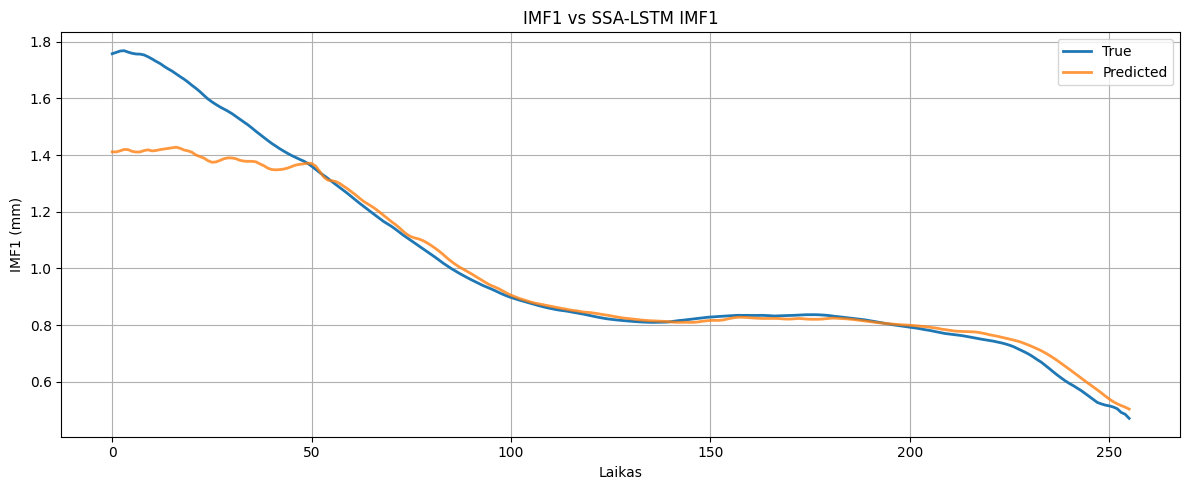

In [43]:
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="True",      linewidth=2)
plt.plot(y_pred, label="Predicted", linewidth=2, alpha=0.8)
plt.title("IMF1 vs SSA-LSTM IMF1")
plt.xlabel("Laikas")
plt.ylabel("IMF1 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF2

In [44]:
pipeline = LSTMNet(
    base_module=LSTMRegressor,
    window_size=14,

    module__hidden_dim=32,
    module__num_layers=3,
    module__dropout=0.2,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=20, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.001,
    batch_size=32,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    criterion=nn.HuberLoss(delta=1.0),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [45]:
pipeline.fit(X_train_IMF2.values, y_train['IMF2'].values)
pred = pipeline.predict(X_test_IMF2.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0098        0.0028     +  0.2765
      2        0.0036        0.0016     +  0.2507
      3        0.0022        0.0023        0.3072
      4        0.0019        0.0039        0.2753
      5        0.0019        0.0020        0.2637
      6        0.0014        0.0009     +  0.2539
      7        0.0011        0.0010        0.2545
      8        0.0010        0.0010        0.2569
      9        0.0009        0.0010        0.2663
     10        0.0007        0.0008     +  0.2517
     11        0.0007        0.0008        0.2553
     12        0.0006        0.0009        0.2638
     13        0.0006        0.0009        0.2828
     14        0.0006        0.0008        0.2727
     15        0.0005        0.0006     +  0.2638
     16        0.0005        0.0005     +  0.2969
     17        0.0005        0.0007        0.2592
     18        0.0006        0.0010        0.2754


In [46]:
y_true = y_test['IMF2'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[14:]
y_pred = np.array(pred).reshape(-1)
# y_pred = np.expm1(y_pred)

# Sulygiuojame ilgius
# min_len = min(len(y_true), len(y_pred))
# y_true = y_true[:min_len]
# y_pred = y_pred[:min_len]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF2 = y_true
y_pred_IMF2 = y_pred

RMSE:     0.0575
MAE:      0.0480
R2:       0.9085
Spearman: 0.9607


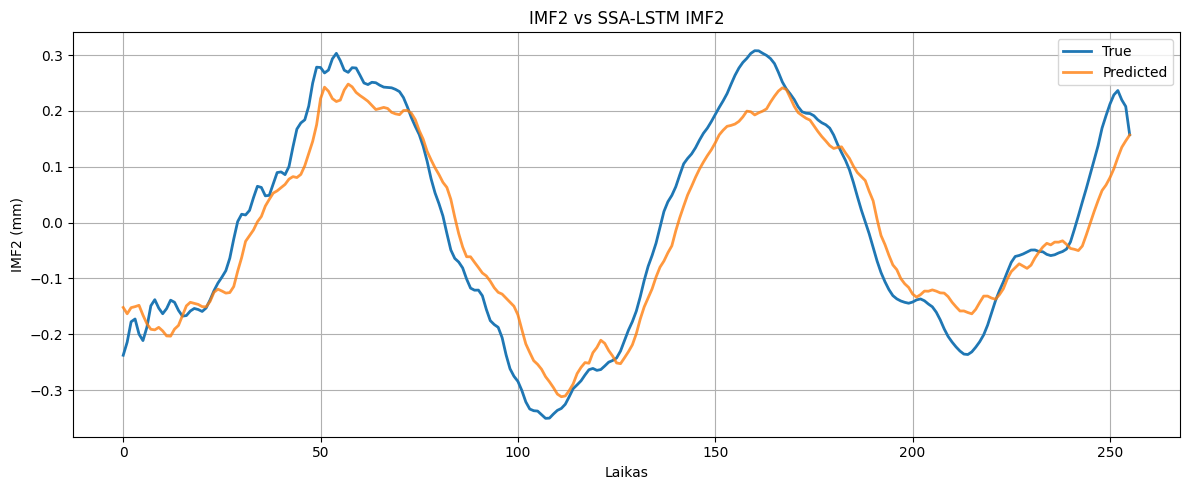

In [47]:
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="True",      linewidth=2)
plt.plot(y_pred, label="Predicted", linewidth=2, alpha=0.8)
plt.title("IMF2 vs SSA-LSTM IMF2")
plt.xlabel("Laikas")
plt.ylabel("IMF2 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF3

In [48]:
pipeline = LSTMNet(
    base_module=LSTMRegressor,
    window_size=14,

    module__hidden_dim=32,
    module__num_layers=4,
    module__dropout=0.2,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=20, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.001,
    batch_size=32,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    # criterion=nn.HuberLoss(delta=1.0),
    criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [49]:
pipeline.fit(X_train_IMF3.values, y_train['IMF3'].values)
pred = pipeline.predict(X_test_IMF3.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0404        0.0218     +  0.3232
      2        0.0209        0.0107     +  0.2920
      3        0.0132        0.0083     +  0.3154
      4        0.0114        0.0072     +  0.2976
      5        0.0099        0.0070     +  0.3339
      6        0.0087        0.0071        0.3045
      7        0.0079        0.0069     +  0.2886
      8        0.0069        0.0074        0.2935
      9        0.0062        0.0076        0.3135
     10        0.0059        0.0080        0.3011
     11        0.0053        0.0082        0.3139
     12        0.0048        0.0089        0.2784
     13        0.0046        0.0078        0.2841
     14        0.0041        0.0071        0.2912
     15        0.0036        0.0069     +  0.2930
     16        0.0035        0.0062     +  0.2836
     17        0.0030        0.0060     +  0.2693
     18        0.0031        0.0068        0.2799


In [50]:
y_true = y_test['IMF3'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[14:]
y_pred = np.array(pred).reshape(-1)
# y_pred = np.expm1(y_pred)

# Sulygiuojame ilgius
# min_len = min(len(y_true), len(y_pred))
# y_true = y_true[:min_len]
# y_pred = y_pred[:min_len]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF3 = y_true
y_pred_IMF3 = y_pred

RMSE:     0.1925
MAE:      0.1436
R2:       0.2905
Spearman: 0.6162


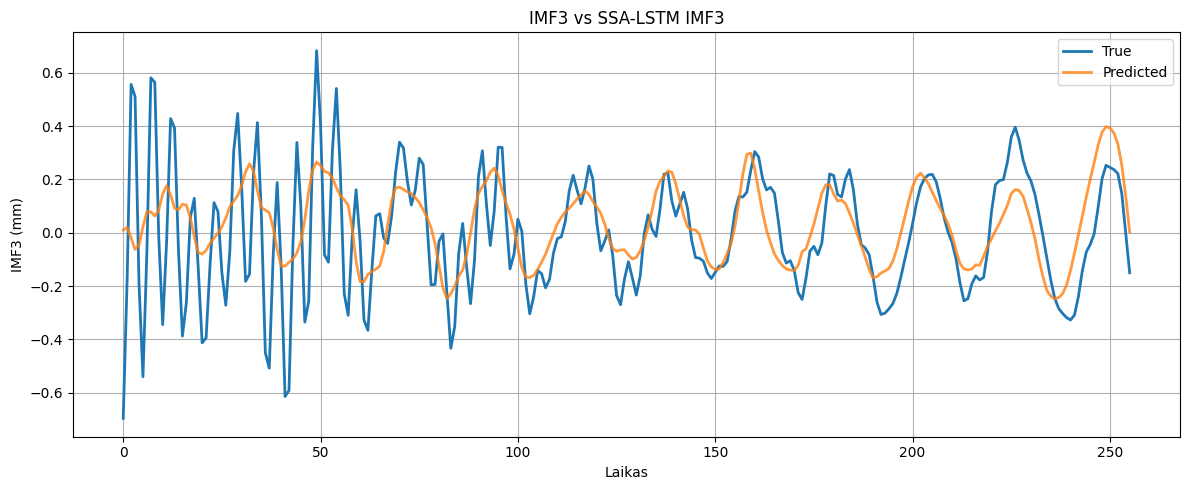

In [51]:
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="True",      linewidth=2)
plt.plot(y_pred, label="Predicted", linewidth=2, alpha=0.8)
plt.title("IMF3 vs SSA-LSTM IMF3")
plt.xlabel("Laikas")
plt.ylabel("IMF3 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF4

In [223]:
class LSTMFCRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Vietoj vieno fc sluoksnio, naudojame Sequential bloką su LeakyReLU.
        # Tai padeda modeliui "ištraukti" triukšmo pikus, kurių paprastas fc nepagautų.
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.1), 
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        # Naudojame paskutinį laiko žingsnį
        return self.fc(out[:, -1, :])

Geriausi parametrai: {'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 64, 'module__num_layers': 1, 'window_size': 7}
Geriausias rezultatas (MSE): 0.7116949869058397

In [313]:
pipeline = LSTMNet(
    base_module=LSTMFCRegressor,
    window_size=3,

    module__hidden_dim=64,
    module__num_layers=1,
    module__dropout=0,
    optimizer__weight_decay = 0,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=10, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.01,
    batch_size=16,
    optimizer=torch.optim.Adam,
    criterion=nn.HuberLoss(delta=0.2),
    # criterion=nn.L1Loss(),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [314]:
pipeline.fit(X_train_IMF4.values, y_train['IMF4'].values)
pred = pipeline.predict(X_test_IMF4.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0848        0.0855     +  0.4399
      2        0.0839        0.0848     +  0.3901
      3        0.0849        0.0835     +  0.3831
      4        0.0809        0.0983        0.3949
      5        0.0802        0.0892        0.3898
      6        0.0759        0.0911        0.3992
      7        0.0749        0.0923        0.4158
      8        0.0743        0.0932        0.3556
      9        0.0711        0.0910        0.3759
     10        0.0673        0.0849        0.3823
     11        0.0665        0.0881        0.3765
     12        0.0676        0.0917        0.4103
Stopping since valid_loss has not improved in the last 10 epochs.


In [31]:
param_grid = {
    'window_size': [3, 5, 7],                # Kiek dienų atgal žiūrime
    'module__hidden_dim': [64, 128],         # Tinklo plotis
    'module__num_layers': [1, 2],            # Sluoksnių skaičius (triukšmui geriau mažiau)
    'lr': [0.01, 0.001],          
    'module__dropout': [0.1, 0.2]            # Epochų skaičius
}
tscv = TimeSeriesSplit(n_splits=3)
# Sukuriame GridSearchCV objektą
# scoring='neg_mean_squared_error' tiesiogiai koreliuoja su jūsų norimu RMSE/MSE

def rmse_for_sequences(y_true, y_pred, **kwargs):
    # Surandame skirtumą tarp ilgių (tai window_size atitikmuo)
    diff = len(y_true) - len(y_pred)
    
    # Nukerpame y_true pradžią, kad ji sutaptų su y_pred ilgiu
    # Nauja scikit-learn funkcija root_mean_squared_error neturi 'squared' parametro
    return root_mean_squared_error(y_true[diff:], y_pred)

# Sukuriame scorer objektą
# greater_is_better=False, nes GridSearchCV siekia maksimizuoti score (o mes norime mažinti RMSE)
custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,                                    # 3-fold Cross Validation
    scoring=custom_rmse, 
    verbose=2
)

# Paleidžiame paiešką
# Naudojame .values, kad išvengtume Pandas indeksų problemų
gs.fit(X_train_IMF4.values, y_train['IMF4'].values)

# Geriausi parametrai
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

# Prognozuojame su geriausiu modeliu
pred = gs.predict(X_test_IMF4.values)

Fitting 3 folds for each of 48 candidates, totalling 144 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.2372        0.2412     +  0.2027
      2        0.2142        0.2368     +  0.0930
      3        0.1948        0.2463        0.0872
      4        0.1700        0.2651        0.0899
      5        0.1624        0.2729        0.0918
      6        0.1566        0.3185        0.0873
      7        0.1150        0.2868        0.0875
      8        0.0924        0.3039        0.0858
      9        0.1124        0.4385        0.0860
     10        0.1178        0.4510        0.0958
     11        0.1464        0.3500        0.0834
     12        0.1068        0.2883        0.0823
     13        0.0887        0.2918        0.1004
     14        0.0634        0.2368     +  0.0943
     15        0.0536        0.2548        0.0973
     16        0.0282        0.2560        0.1072
     17        0.0170        0.2482   

In [315]:
y_true = y_test['IMF4'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[3:]
y_pred = np.array(pred).reshape(-1)
# y_pred = np.expm1(y_pred)

# Sulygiuojame ilgius
# min_len = min(len(y_true), len(y_pred))
# y_true = y_true[:min_len]
# y_pred = y_pred[:min_len]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF4 = y_true[11:]
y_pred_IMF4 = y_pred[11:]

RMSE:     0.8093
MAE:      0.5825
R2:       -0.1229
Spearman: 0.1374


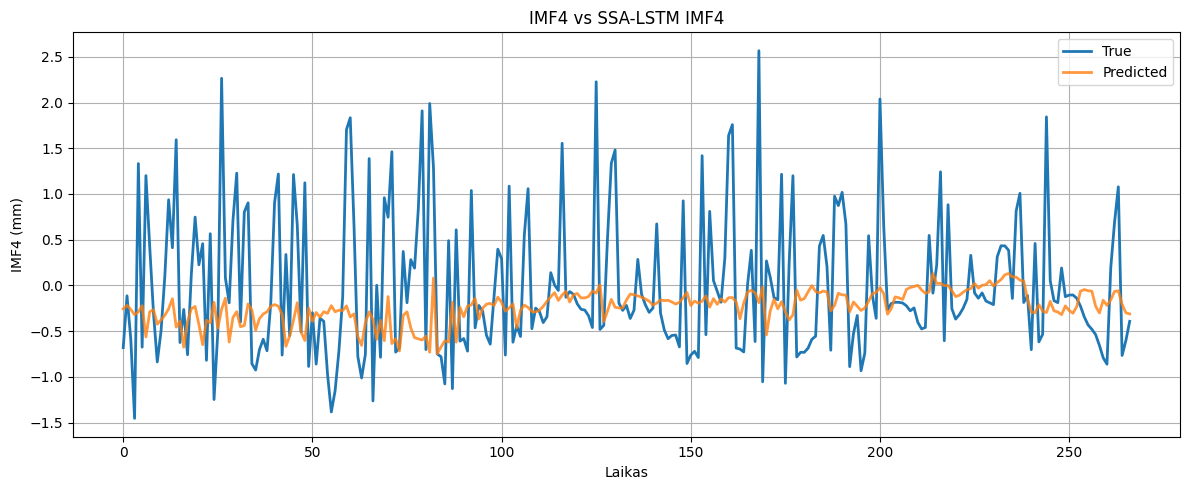

In [316]:
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="True",      linewidth=2)
plt.plot(y_pred, label="Predicted", linewidth=2, alpha=0.8)
plt.title("IMF4 vs SSA-LSTM IMF4")
plt.xlabel("Laikas")
plt.ylabel("IMF4 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### SSA-LSTM rezultatai

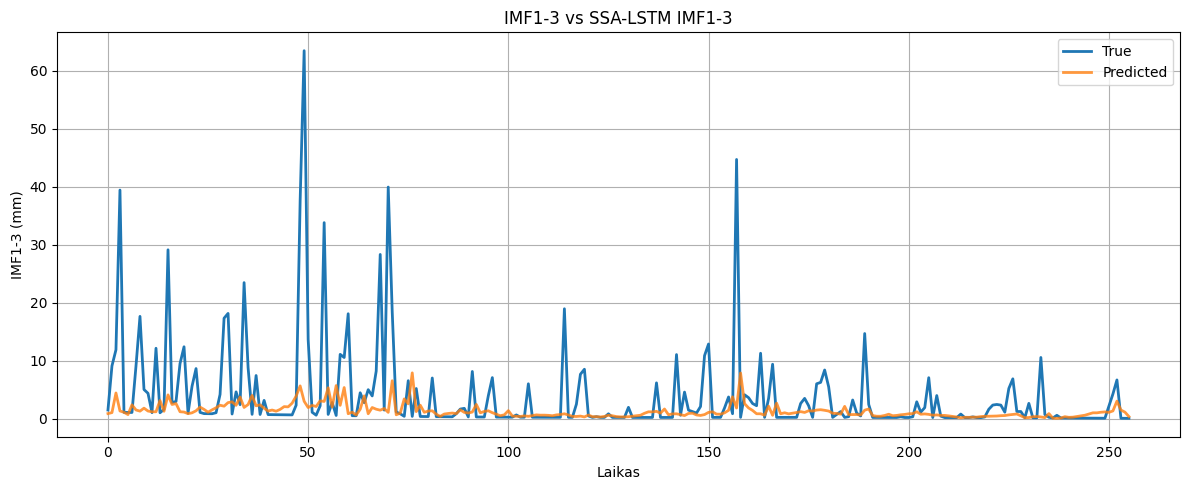

In [310]:
y_true_final = np.expm1(y_true_IMF1 + y_true_IMF2 + y_true_IMF3 + y_true_IMF4)
y_pred_final = np.expm1(y_pred_IMF1 + y_pred_IMF2 + y_pred_IMF3 + y_pred_IMF4)

plt.figure(figsize=(12, 5))
plt.plot(y_true_final, label="True",      linewidth=2)
plt.plot(y_pred_final, label="Predicted", linewidth=2, alpha=0.8)
plt.title("IMF1-3 vs SSA-LSTM IMF1-3")
plt.xlabel("Laikas")
plt.ylabel("IMF1-3 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [301]:
rmse = np.sqrt(mean_squared_error(y_true_final, y_pred_final))
mae  = mean_absolute_error(y_true_final, y_pred_final)
r2   = r2_score(y_true_final, y_pred_final)
spearman_corr, _ = spearmanr(y_true_final, y_pred_final)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

RMSE:     8.2243
MAE:      3.5587
R2:       -0.1002
Spearman: 0.4113
